In [16]:
# Package
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

In [4]:
# Parameters
rng = np.random.default_rng(42)

mu, sigma, r = 0.16905, 0.4907, 0.0011888
t, T, Delta = 0.0, 0.291667, 10/252
S0, K, M, N = 152.51, 170.0, 100, 100_000

In [20]:
def put_bs(t, S):
    tau = T - t
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*tau) / (sigma*np.sqrt(tau))
    d2 = d1 - sigma*np.sqrt(tau)
    return S*(norm.cdf(d1)-1) + K*np.exp(-r*tau)*(1-norm.cdf(d2))
P0 = put_bs(t, S0)
print(f"Put option price at t={t:.4f}: {P0:.4f}")

Put option price at t=0.0000: 27.0990


In [21]:
tau = T - t
d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*tau) / (sigma*np.sqrt(tau))
d2 = d1 - sigma*np.sqrt(tau)

delta = norm.cdf(d1) - 1
gamma = norm.pdf(d1) / (S0*sigma*np.sqrt(tau))
theta = -S0*sigma*norm.pdf(d1)/(2*np.sqrt(tau)) + r*K*np.exp(-r*tau)*(1-norm.cdf(d2))
print(f"Delta: {delta:.4f}, Gamma: {gamma:.4f}, Theta: {theta:.4f}")

Delta: -0.6087, Gamma: 0.0095, Theta: -26.4662


In [9]:
X = rng.normal((mu - 0.5*sigma**2)*Delta, sigma*np.sqrt(Delta), N)
S1 = S0*np.exp(X)

In [10]:
L_full = M*(delta*S0*(1-np.exp(X)) + put_bs(t+Delta, S1) - P0)
L_lin = np.full(N, M*theta*Delta)
L_quad = M*theta*Delta + 0.5*M*S0**2*gamma*X**2

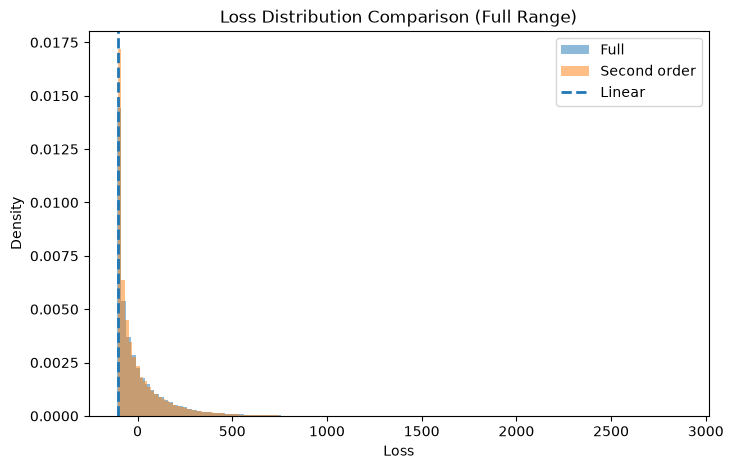

In [14]:
plt.figure(figsize=(8,5))
plt.hist(L_full, bins=120, density=True, alpha=0.5, label="Full")
plt.hist(L_quad, bins=120, density=True, alpha=0.5, label="Second order")
plt.axvline(L_lin[0], linestyle="--", linewidth=2, label="Linear")
plt.xlabel("Loss")
plt.ylabel("Density")
plt.title("Loss Distribution Comparison (Full Range)")
plt.legend()
plt.show()

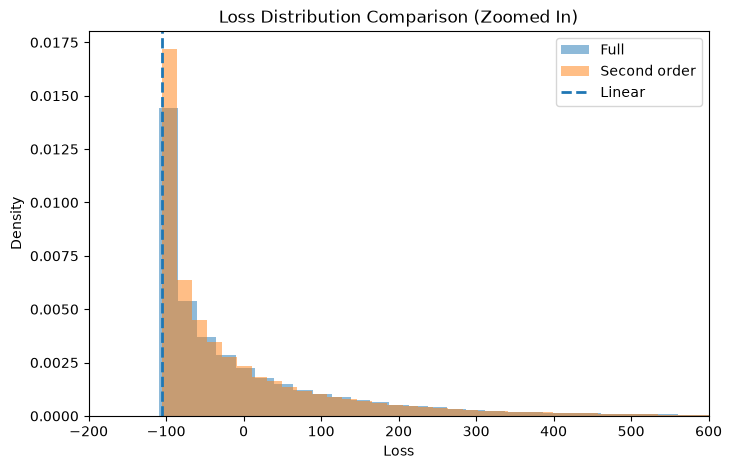

In [15]:
plt.figure(figsize=(8,5))
plt.hist(L_full, bins=120, density=True, alpha=0.5, label="Full")
plt.hist(L_quad, bins=120, density=True, alpha=0.5, label="Second order")
plt.axvline(L_lin[0], linestyle="--", linewidth=2, label="Linear")
plt.xlim(-200, 600)
plt.xlabel("Loss")
plt.ylabel("Density")
plt.title("Loss Distribution Comparison (Zoomed In)")
plt.legend()
plt.show()

In [19]:
results = pd.DataFrame({
    name: [np.mean(L), np.std(L), np.quantile(L, 0.95), np.quantile(L, 0.99)]
    for name, L in [("Full", L_full), ("Linear", L_lin), ("Second Order", L_quad)]
}, index=["Mean", "Std", "95% Quantile", "99% Quantile"]).T

results.round(4)

,Mean,Std,95% Quantile,99% Quantile
Full,0.4589,155.4272,301.7795,601.7857
Linear,-105.0248,0.0000,-105.0248,-105.0248
Second Order,-0.1158,148.8233,297.5390,594.5140
